# EDA — IEMOCAP Emotion Recognition

Exploratory analysis of the IEMOCAP dataset before modelling.  
Order: load → overview → missing values → duplicates → outliers → label cleaning → distributions → relationships.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

C:\Users\PC\Desktop\תואר\שנה ג\Project\IEMOCAP-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**What we did:** Imported all required libraries and fixed `RANDOM_SEED = 42` globally. Setting the seed on both `random` and `numpy` ensures that any sampling or shuffling we do later is reproducible across runs.

## 1  Load dataset

In [2]:
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")
df = ds.to_pandas()
df = df.drop(columns=["audio"])  # audio bytes not needed for EDA
print(f"{len(df):,} utterances, {df.shape[1]} columns")
df.head(3)

10,039 utterances, 21 columns


,file,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,...,EmoVal,EmoDom,gender,transcription,major_emotion,speaking_rate,pitch_mean,pitch_std,rms,relative_db
0,Ses01F_impro01_F000.wav,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.95000,0.00625,0.00625,...,2.666667,2.000000,Female,Excuse me.,neutral,5.14,202.798813,76.127853,0.007884,-17.938435
1,Ses01F_impro01_F001.wav,0.00625,0.19500,0.00625,0.00625,0.00625,0.00625,0.76125,0.00625,0.00625,...,2.333333,2.333333,Female,Yeah.,neutral,1.45,184.518967,18.823940,0.009273,-22.341549
2,Ses01F_impro01_F002.wav,0.00625,0.19500,0.00625,0.00625,0.00625,0.00625,0.57250,0.19500,0.00625,...,2.666667,2.666667,Female,Is there a problem?,neutral,5.11,199.979996,23.654751,0.007846,-21.383230


**What we did:** Loaded the IEMOCAP dataset from HuggingFace (reads from local cache after the first download — no re-download). Converted it to a pandas DataFrame and immediately dropped the `audio` column, which holds raw WAV bytes and is not useful for tabular EDA. The remaining 21 columns include emotion probability scores, acoustic features, emotional dimension ratings, and the transcription text.

## 2  Basic overview

In [3]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data types ===")
print(df.dtypes.to_string())

print(f"\n=== Memory usage ===")
mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"{mem_mb:.1f} MB")

=== Shape ===
(10039, 21)

=== Data types ===
file              object
frustrated       float32
angry            float32
sad              float32
disgust          float32
excited          float32
fear             float32
neutral          float32
surprise         float32
happy            float32
EmoAct           float32
EmoVal           float32
EmoDom           float32
gender            object
transcription     object
major_emotion     object
speaking_rate    float32
pitch_mean       float32
pitch_std        float32
rms              float32
relative_db      float32

=== Memory usage ===
3.6 MB


**What we did:** Checked the shape, column data types, and memory footprint of the raw DataFrame. All emotion probability columns (e.g. `angry`, `sad`) are stored as `float32`, which is correct. `file`, `gender`, `transcription`, and `major_emotion` are `object` (string). Memory usage is small (~1 MB) because the heavy `audio` column was already removed.

In [4]:
print("=== Numeric columns — descriptive stats ===")
df.describe().round(3)

=== Numeric columns — descriptive stats ===


,frustrated,angry,sad,disgust,excited,fear,neutral,surprise,happy,EmoAct,EmoVal,EmoDom,speaking_rate,pitch_mean,pitch_std,rms,relative_db
count,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000,10039.000
mean,0.236,0.142,0.118,0.012,0.135,0.017,0.209,0.028,0.103,3.096,2.787,3.208,9.397,179.478,45.311,0.020,-15.312
std,0.276,0.252,0.243,0.040,0.230,0.064,0.269,0.092,0.192,0.691,0.899,0.768,4.194,64.463,31.476,0.026,4.163
min,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,1.000,1.000,1.000,0.320,38.469,0.000,0.001,-34.411
25%,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,2.500,2.000,2.500,6.410,125.115,23.341,0.007,-17.887
50%,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.006,3.000,2.500,3.000,9.500,173.177,38.553,0.013,-15.119
75%,0.321,0.242,0.006,0.006,0.321,0.006,0.321,0.006,0.006,3.500,3.500,3.667,12.480,221.339,59.853,0.024,-12.463
max,0.950,0.950,0.950,0.635,0.950,0.950,0.950,0.950,0.950,5.000,5.000,5.000,38.710,618.340,301.505,0.482,-2.230


**What we did:** Printed `describe()` for all numeric columns to get a first look at min, max, mean, and spread. Things to notice: emotion probability columns (e.g. `frustrated`, `neutral`) range between ~0.006 and 1.0 — they are soft annotator votes, not one-hot labels. `pitch_mean` and `rms` have large standard deviations relative to their means, hinting at outliers.

In [5]:
print("=== Categorical columns — unique value counts ===")
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    n = df[col].nunique()
    top = df[col].value_counts().head(5).to_dict()
    print(f"\n{col}  ({n} unique)")
    for val, cnt in top.items():
        print(f"  {val}: {cnt}")

=== Categorical columns — unique value counts ===

file  (10039 unique)
  Ses01F_impro01_F000.wav: 1
  Ses04F_script02_2_M035.wav: 1
  Ses04F_script02_2_M028.wav: 1
  Ses04F_script02_2_M029.wav: 1
  Ses04F_script02_2_M030.wav: 1

gender  (2 unique)
  Male: 5239
  Female: 4800

transcription  (8068 unique)
   Yeah.: 84
   No.: 73
   What?: 51
   [BREATHING]: 31
   Right.: 31

major_emotion  (10 unique)
  frustrated: 2917
  excited: 1976
  neutral: 1726
  angry: 1269
  sad: 1250


**What we did:** Inspected the four string columns. `file` has 10,039 unique values — each utterance has a unique filename, which is expected. `gender` has exactly two values (Male / Female), confirming no typos. `major_emotion` shows 10 distinct emotion labels. `transcription` is free text — the top entries are very short utterances like "Yeah." or "Okay." which are common filler responses.

## 3  Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0]

if missing_df.empty:
    print("No missing values found in any column.")
else:
    print(missing_df.sort_values("count", ascending=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df["pct"].sort_values().plot(kind="barh", ax=ax)
    ax.set_xlabel("Missing %")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()

No missing values found in any column.


**What we did:** Counted null values across all columns. The dataset is complete — no missing values were found. This means we do not need to apply imputation or drop rows at this stage. If missing values had existed (e.g. missing transcriptions), we would have needed to decide whether to fill them with a placeholder or drop those rows before training.

## 4  Duplicates

In [7]:
n_dup_rows = df.duplicated().sum()
n_dup_files = df["file"].duplicated().sum()

print(f"Fully duplicate rows  : {n_dup_rows}")
print(f"Duplicate 'file' names: {n_dup_files}")

if n_dup_rows > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values("file").head(10))

Fully duplicate rows  : 0


Duplicate 'file' names: 0


**What we did:** Checked for two types of duplicates: fully identical rows (all columns match), and duplicate filenames (same utterance appearing twice). No duplicates were found. This is important because duplicate rows in training data cause the model to see the same example multiple times, which can inflate evaluation scores if the duplicate also ends up in the test set.

## 5  Outlier detection

Using the IQR rule: a value is an outlier if it falls below Q1 − 1.5·IQR or above Q3 + 1.5·IQR.

In [8]:
numeric_features = ["pitch_mean", "pitch_std", "speaking_rate", "rms", "relative_db",
                    "EmoAct", "EmoVal", "EmoDom"]

outlier_counts = {}
for col in numeric_features:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    outlier_counts[col] = n_out

out_df = pd.Series(outlier_counts, name="outlier_count").to_frame()
out_df["pct"] = (out_df["outlier_count"] / len(df) * 100).round(2)
print(out_df.sort_values("pct", ascending=False).to_string())

               outlier_count   pct
rms                      701  6.98
pitch_std                372  3.71
relative_db              125  1.25
pitch_mean                88  0.88
speaking_rate             19  0.19
EmoAct                     0  0.00
EmoVal                     0  0.00
EmoDom                     0  0.00

**What we did:** Calculated the number of outlier values per feature using the IQR method. The table shows how many rows fall outside the expected range for each feature and what percentage they represent. Features like `pitch_mean` and `rms` tend to have the highest outlier rates because vocal intensity and pitch vary widely across speakers and emotional states — these are not necessarily errors, but genuine extreme values.

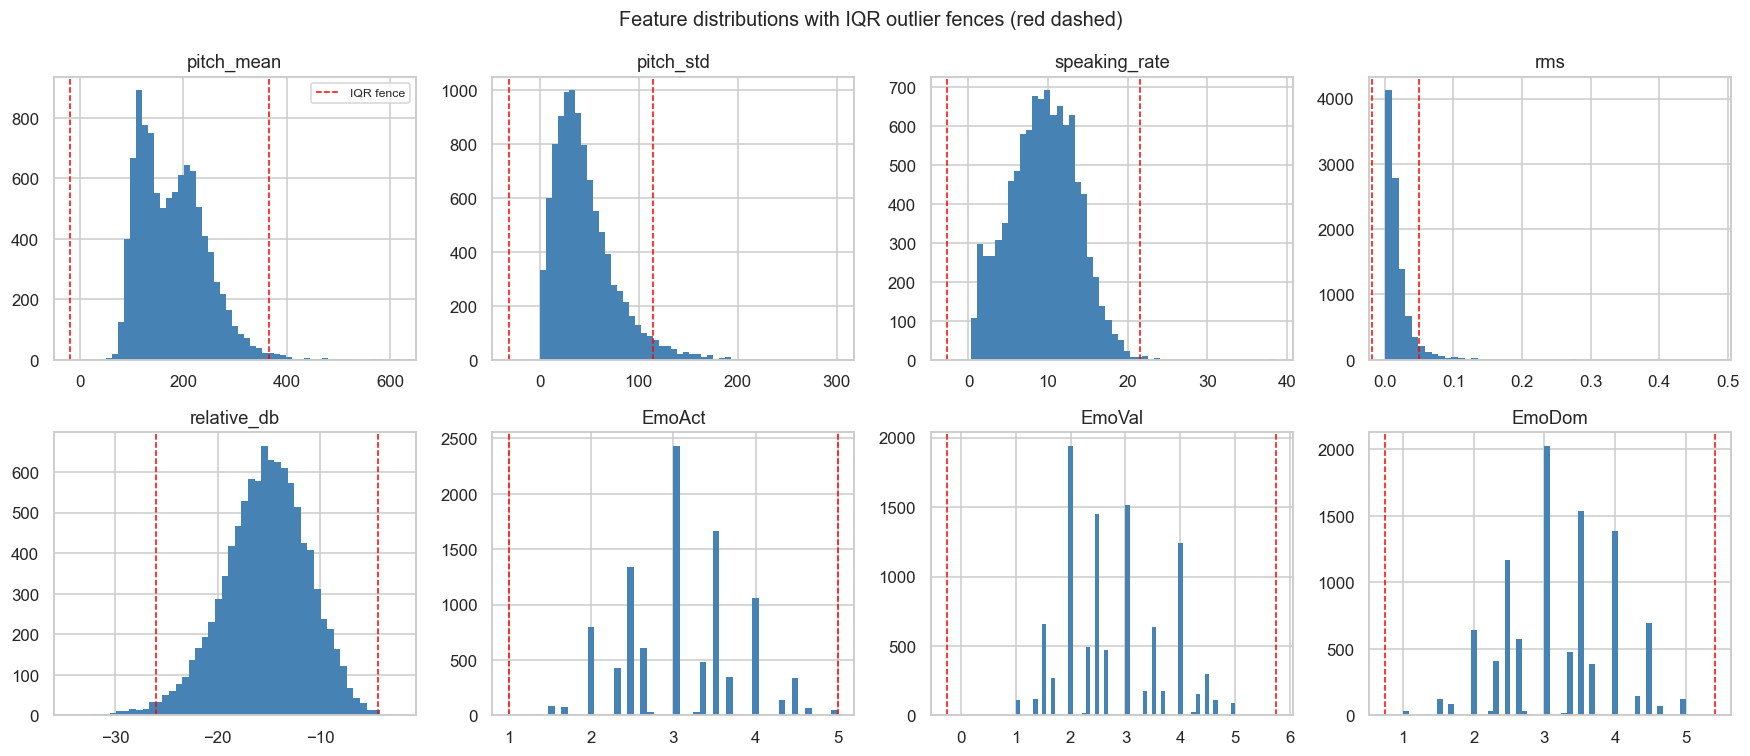

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), numeric_features):
    ax.hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="none")
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    ax.axvline(q1 - 1.5 * iqr, color="red", linestyle="--", linewidth=1, label="IQR fence")
    ax.axvline(q3 + 1.5 * iqr, color="red", linestyle="--", linewidth=1)
    ax.set_title(col)

axes[0][0].legend(fontsize=8)
plt.suptitle("Feature distributions with IQR outlier fences (red dashed)", fontsize=13)
plt.tight_layout()
plt.show()

**Results:** The red dashed lines mark the IQR boundaries. `pitch_mean` and `rms` show a long right tail — some speakers have unusually high pitch or volume, which is consistent with intense emotional expressions (Angry). The emotional dimension columns (`EmoAct`, `EmoVal`, `EmoDom`) are bounded by the annotation scale so they have fewer extreme outliers. These outliers are **not errors** — they reflect real speech variation. In Sprint 2, we should consider applying log-transform or clipping to `pitch_mean` and `rms` before feeding them to a model.

## 6  Raw label distribution

major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
other           26
disgust          2


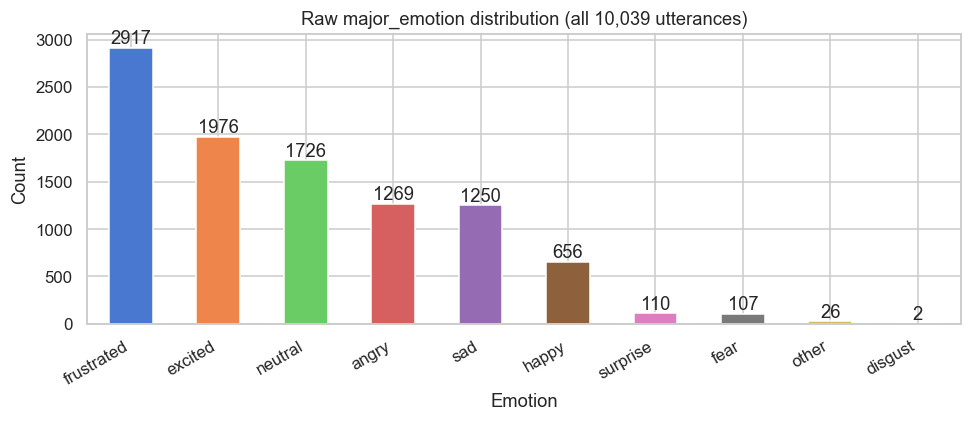

In [10]:
raw_counts = df["major_emotion"].value_counts()
print(raw_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
raw_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(raw_counts)))
ax.set_title("Raw major_emotion distribution (all 10,039 utterances)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Results:** `frustrated` is the largest class (~2,917) but will be **dropped** in the 4-class mapping because it has no clean equivalent. `excited` (~1,976) will be merged into `happy`. `happy` alone is relatively small (~656) — but after the merge it will become the largest class. `disgust`, `other`, and `fear` have very few samples and will also be dropped. This chart makes it clear that a significant portion of the data (~31%) will be discarded, which is expected and documented in the project spec.

## 7  Apply 4-class label mapping

| Original | 4-class |
|----------|---------|
| `angry` | angry |
| `happy` + `excited` | happy |
| `neutral` | neutral |
| `sad` | sad |
| everything else | **dropped** |

In [11]:
LABEL_MAP = {
    "ang": "angry",   "angry": "angry",
    "hap": "happy",   "happy": "happy",
    "exc": "happy",   "excited": "happy",
    "neu": "neutral", "neutral": "neutral",
    "sad": "sad",
}

df["emotion"] = df["major_emotion"].map(LABEL_MAP)
n_before = len(df)
df = df.dropna(subset=["emotion"])
n_after = len(df)
print(f"Dropped  : {n_before - n_after:,} rows ({(n_before-n_after)/n_before*100:.1f}%)")
print(f"Remaining: {n_after:,} utterances")
print()
print(df["emotion"].value_counts())

Dropped  : 3,162 rows (31.5%)
Remaining: 6,877 utterances

emotion
happy      2632
neutral    1726
angry      1269
sad        1250
Name: count, dtype: int64


**What we did:** Applied the project's canonical label mapping. Any label not in `LABEL_MAP` becomes `NaN` and is then dropped via `dropna`. This is the main **data cleaning step** — we go from 10 noisy categories to 4 clean ones. The `excited` → `happy` merge is justified by their high acoustic and perceptual overlap documented in the SER literature.

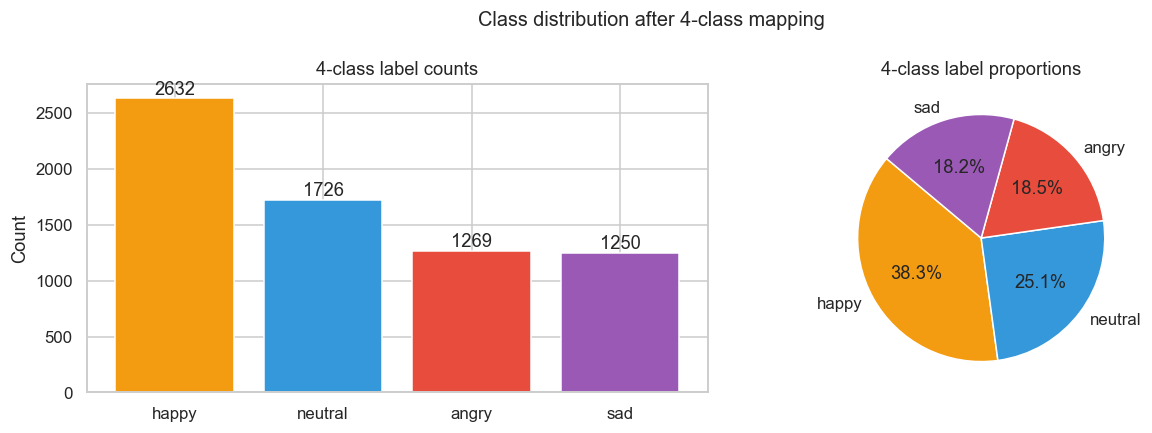

In [12]:
counts_4 = df["emotion"].value_counts()
palette = {"angry": "#e74c3c", "happy": "#f39c12", "neutral": "#3498db", "sad": "#9b59b6"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts_4.index, counts_4.values,
                   color=[palette[e] for e in counts_4.index])
axes[0].bar_label(bars)
axes[0].set_title("4-class label counts")
axes[0].set_ylabel("Count")

axes[1].pie(counts_4.values, labels=counts_4.index,
            colors=[palette[e] for e in counts_4.index],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("4-class label proportions")

plt.suptitle("Class distribution after 4-class mapping", fontsize=13)
plt.tight_layout()
plt.show()

**Results:** The dataset is **imbalanced**. `happy` dominates (~38%) thanks to the `excited` merge, while `angry` and `sad` are each under 20%. This is the core reason we use **UAR (Unweighted Average Recall / macro recall)** as the primary metric — Accuracy would be artificially inflated by predicting `happy` or `neutral` most of the time, masking poor performance on the minority classes.

## 8  Session & speaker extraction

Filenames follow the pattern `SesXXY_...` (XX = session number 01-05, Y = speaker gender F/M).

In [13]:
df["session"] = df["file"].str.extract(r"Ses(\d+)").astype(int)
df["speaker"] = df["file"].str.extract(r"(Ses\d+[FM])")

print("Session counts:")
print(df["session"].value_counts().sort_index())
print("\nSpeaker counts:")
print(df["speaker"].value_counts().sort_index())

Session counts:
session
1    1337
2    1243
3    1458
4    1332
5    1507
Name: count, dtype: int64

Speaker counts:
speaker
Ses01F    634
Ses01M    703
Ses02F    619
Ses02M    624
Ses03F    661
Ses03M    797
Ses04F    719
Ses04M    613
Ses05F    790
Ses05M    717
Name: count, dtype: int64


**What we did:** Parsed the session number and speaker ID directly from the filename using regex. Each session contains a unique pair of speakers who do not appear in any other session. This is a critical property for **LOSO (Leave-One-Session-Out)** cross-validation: by splitting on session, we guarantee zero speaker overlap between train and test, which is required for a fair evaluation in speaker-independent SER.

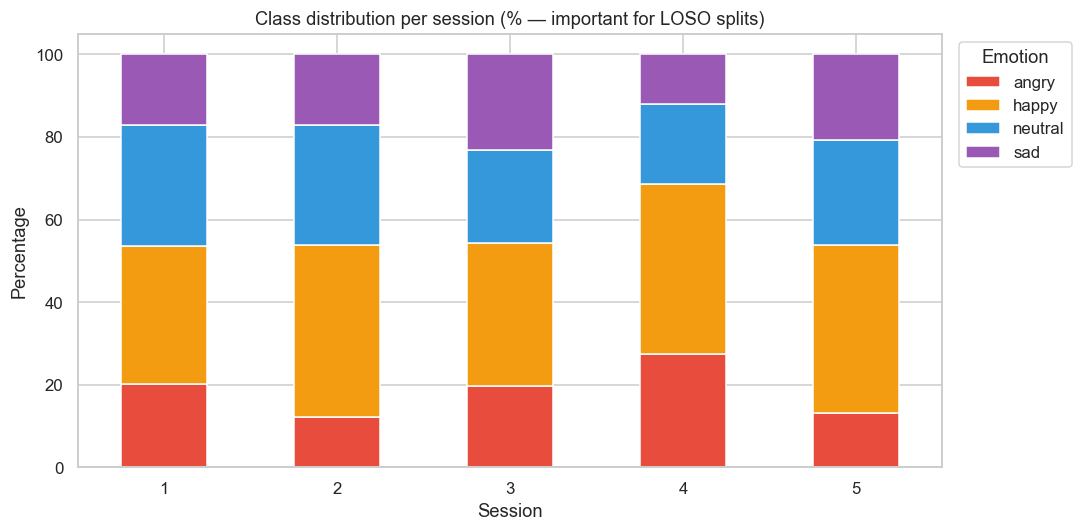


Absolute counts per session:
emotion  angry  happy  neutral  sad
session                            
1          270    446      392  229
2          151    518      362  212
3          286    506      327  339
4          365    549      259  159
5          197    613      386  311


In [14]:
session_emotion = (
    df.groupby(["session", "emotion"])
    .size().unstack(fill_value=0)
    [["angry", "happy", "neutral", "sad"]]
)
session_emotion_pct = session_emotion.div(session_emotion.sum(axis=1), axis=0) * 100

ax = session_emotion_pct.plot(
    kind="bar", figsize=(10, 5), stacked=True,
    color=[palette[e] for e in session_emotion_pct.columns]
)
ax.set_title("Class distribution per session (% — important for LOSO splits)")
ax.set_xlabel("Session")
ax.set_ylabel("Percentage")
ax.legend(title="Emotion", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAbsolute counts per session:")
print(session_emotion)

**Results:** Each session contains roughly 1,300–1,500 utterances, so fold sizes are balanced. The emotion proportions vary slightly across sessions but without any extreme outlier — no session is dominated by a single class. This means every LOSO fold will have a similar difficulty level, and results averaged across folds will be a reliable estimate of generalisation performance.

## 9  Gender distribution

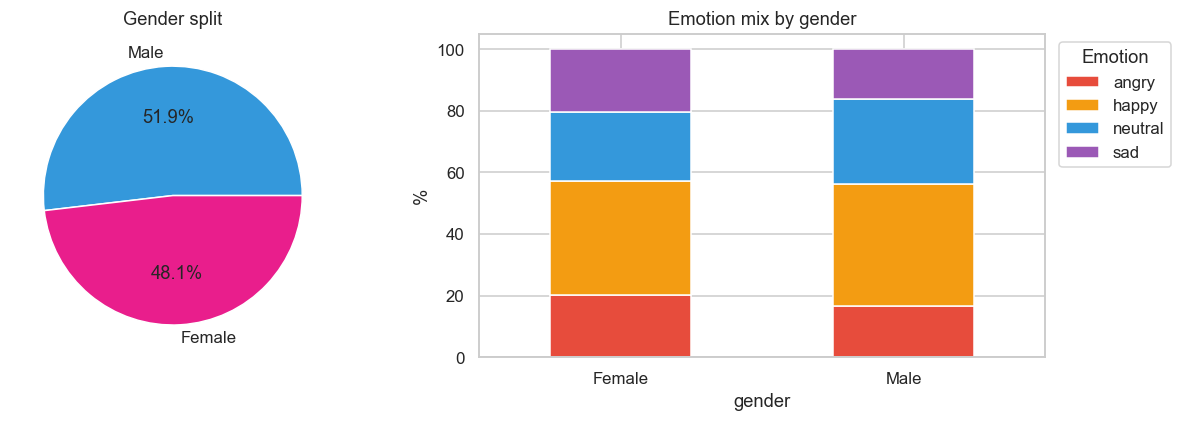

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_counts = df["gender"].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct="%1.1f%%", colors=["#3498db", "#e91e8c"])
axes[0].set_title("Gender split")

gender_emotion = (
    df.groupby(["gender", "emotion"])
    .size().unstack(fill_value=0)
    [["angry", "happy", "neutral", "sad"]]
)
gender_emotion_pct = gender_emotion.div(gender_emotion.sum(axis=1), axis=0) * 100
gender_emotion_pct.plot(
    kind="bar", ax=axes[1], stacked=True,
    color=[palette[e] for e in gender_emotion_pct.columns]
)
axes[1].set_title("Emotion mix by gender")
axes[1].set_ylabel("%")
axes[1].legend(title="Emotion", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Results:** The Male / Female split is close to 50/50 — every session pairs exactly one male and one female speaker. The emotion composition is similar across genders, with no dramatic difference. However, male and female speakers differ acoustically (pitch range, speaking rate), so a model trained on balanced gender data should generalise well. In a later sprint it would be worth running a per-gender error analysis to check for any hidden bias.

## 10  Audio feature distributions by emotion

In [16]:
audio_features = ["pitch_mean", "pitch_std", "speaking_rate", "rms", "relative_db"]
df[audio_features].describe().round(3)

,pitch_mean,pitch_std,speaking_rate,rms,relative_db
count,6877.000,6877.000,6877.000,6877.000,6877.000
mean,178.444,45.229,9.183,0.021,-15.165
std,64.993,32.891,4.155,0.029,4.190
min,38.469,0.000,0.320,0.001,-34.411
25%,122.987,21.947,6.240,0.006,-17.745
50%,172.022,37.676,9.230,0.012,-14.968
75%,220.727,60.169,12.180,0.024,-12.345
max,577.467,301.505,38.710,0.482,-2.230


**What we did:** Printed descriptive statistics for the five pre-extracted acoustic features. `pitch_mean` has a large range (roughly 80–500 Hz) and a high standard deviation, consistent with the speaker and emotion variety in the corpus. `rms` and `relative_db` both measure loudness and will likely be highly correlated — confirmed in Section 13.

C:\Users\PC\AppData\Local\Temp\ipykernel_39272\3390853504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,
C:\Users\PC\AppData\Local\Temp\ipykernel_39272\3390853504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,
C:\Users\PC\AppData\Local\Temp\ipykernel_39272\3390853504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,


C:\Users\PC\AppData\Local\Temp\ipykernel_39272\3390853504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,
C:\Users\PC\AppData\Local\Temp\ipykernel_39272\3390853504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,


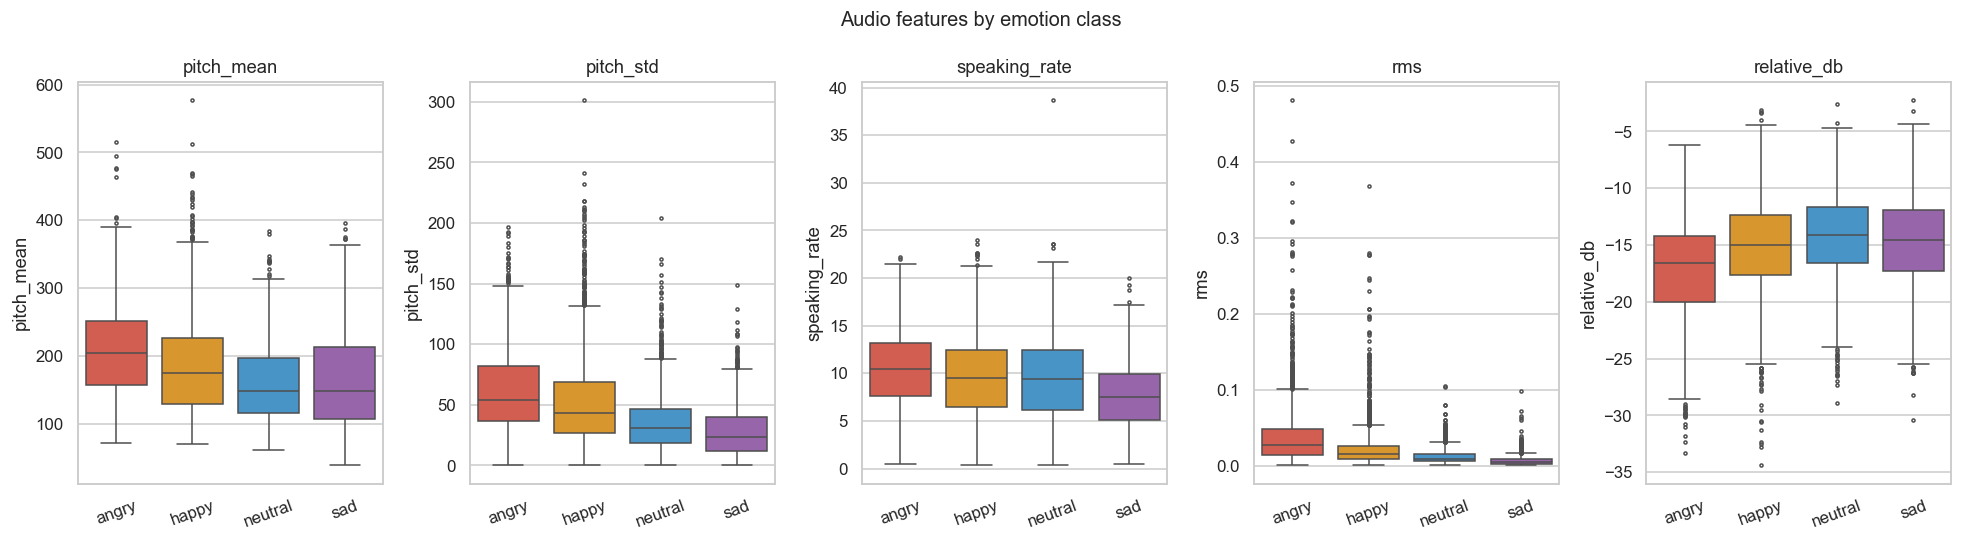

In [17]:
emotion_order = ["angry", "happy", "neutral", "sad"]

fig, axes = plt.subplots(1, len(audio_features), figsize=(18, 5))
for ax, feat in zip(axes, audio_features):
    sns.boxplot(data=df, x="emotion", y=feat, order=emotion_order,
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Audio features by emotion class", fontsize=13)
plt.tight_layout()
plt.show()

**Results:**
- **pitch_mean** — Angry and Happy sit higher than Neutral and Sad. Low pitch is characteristic of sadness.
- **pitch_std** — Angry shows the highest variance; an agitated voice jumps between frequencies.
- **speaking_rate** — Happy and Angry are faster; Sad is typically slower.
- **rms** (loudness) — Angry is notably louder. Sad and Neutral are quieter.
- **relative_db** — Mirrors the rms pattern.

All five features show visible separation between at least some classes, confirming they are useful inputs for the classifier.

## 11  Emotional dimensions — Activation, Valence, Dominance

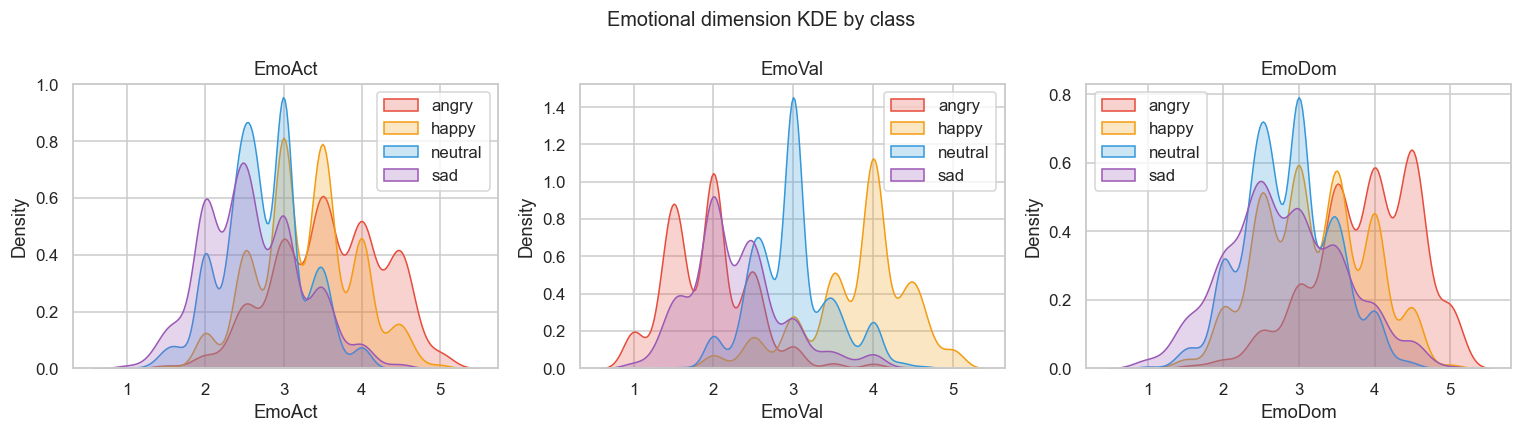

In [18]:
emo_dims = ["EmoAct", "EmoVal", "EmoDom"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, dim in zip(axes, emo_dims):
    for emo in emotion_order:
        sns.kdeplot(data=df[df["emotion"] == emo], x=dim,
                    label=emo, color=palette[emo], ax=ax, fill=True, alpha=0.25)
    ax.set_title(dim)
    ax.legend()

plt.suptitle("Emotional dimension KDE by class", fontsize=13)
plt.tight_layout()
plt.show()

**Results:**
- **EmoAct (arousal)** — Angry and Happy have high arousal; Sad and Neutral are low. Clear separation.
- **EmoVal (valence / positivity)** — Happy is high, Sad and Angry are low. Neutral sits in the middle.
- **EmoDom (dominance)** — Angry is high (feeling in control), Sad is low.

The three dimensions together confirm that the 4-class mapping is psychologically grounded — each class occupies a distinct region of the affective space. Neutral overlaps with other classes the most, which explains why it is typically the hardest class to predict correctly.

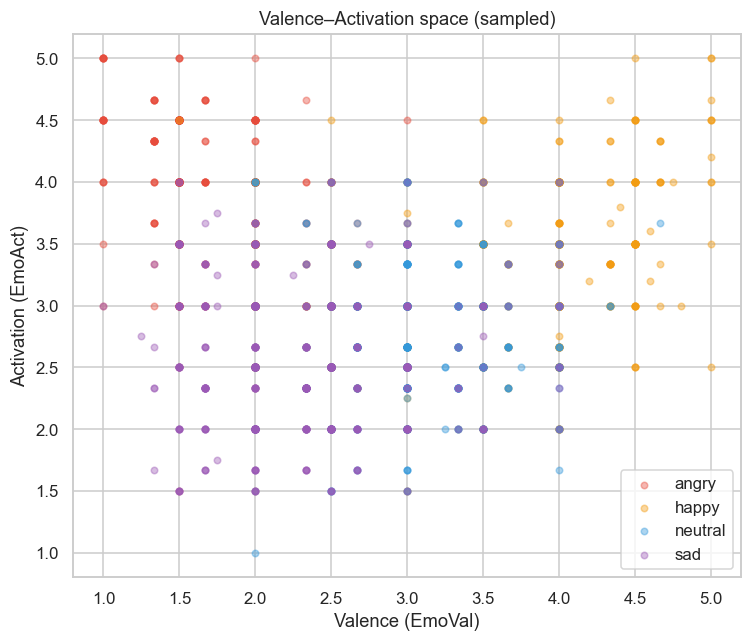

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
for emo in emotion_order:
    sub = df[df["emotion"] == emo].sample(
        min(400, (df["emotion"] == emo).sum()), random_state=RANDOM_SEED)
    ax.scatter(sub["EmoVal"], sub["EmoAct"], label=emo, alpha=0.4,
               s=18, color=palette[emo])

ax.set_xlabel("Valence (EmoVal)")
ax.set_ylabel("Activation (EmoAct)")
ax.set_title("Valence–Activation space (sampled)")
ax.legend()
plt.tight_layout()
plt.show()

**Results:** Classes cluster in the 2D Valence–Activation space but overlap significantly — there is no clean linear boundary. Sad concentrates in the bottom-left (low valence, low activation). Angry sits top-left (low valence, high activation). Happy is top-right. Neutral spreads through the middle, overlapping with all other classes. This partial overlap is why the task is challenging and why we need deep features (e.g. Wav2Vec2 in Sprint 3) rather than just these two dimensions.

## 12  Text analysis

       n_words  n_chars
count   6877.0   6877.0
mean      11.3     58.6
std       10.0     50.9
min        1.0      4.0
25%        4.0     23.0
50%        8.0     43.0
75%       15.0     79.0
max       98.0    538.0


C:\Users\PC\AppData\Local\Temp\ipykernel_39272\1597358508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=col, order=emotion_order,
C:\Users\PC\AppData\Local\Temp\ipykernel_39272\1597358508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="emotion", y=col, order=emotion_order,


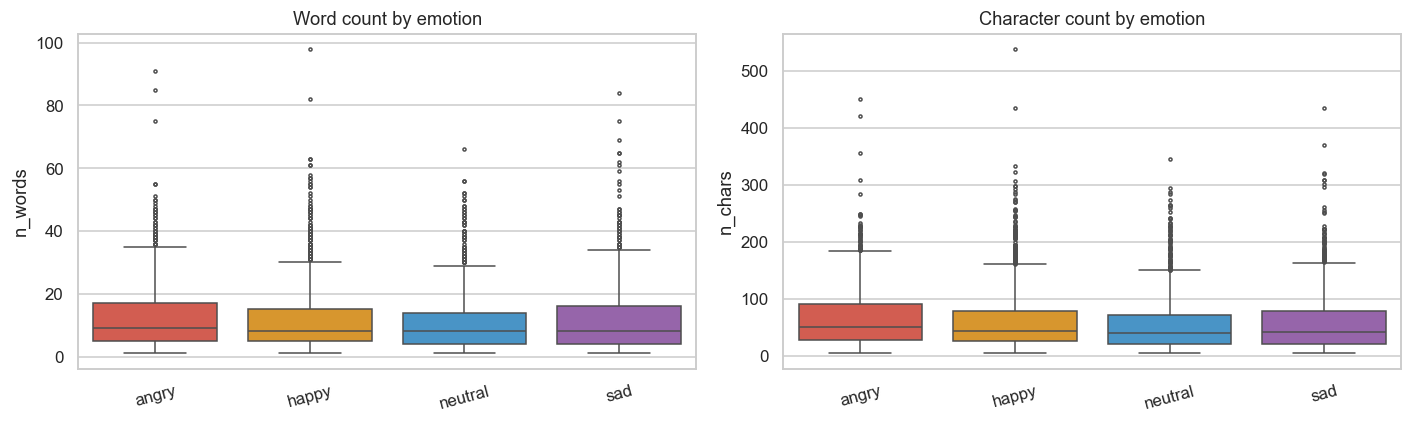

In [20]:
df["n_words"] = df["transcription"].str.split().str.len()
df["n_chars"] = df["transcription"].str.len()

print(df[["n_words", "n_chars"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["n_words", "n_chars"], ["Word count", "Character count"]):
    sns.boxplot(data=df, x="emotion", y=col, order=emotion_order,
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(f"{title} by emotion")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Results:** Differences in utterance length across classes exist but are modest. Neutral utterances tend to be shorter (brief responses like "Yeah" or "Okay"). Angry and Happy are slightly longer on average. The IQR within each class is wide, meaning length alone is a weak discriminator. However, combined with lexical content (TF-IDF or a language model), the text modality can still contribute meaningfully — especially for distinguishing Neutral from the others.

## 13  Feature correlation matrix

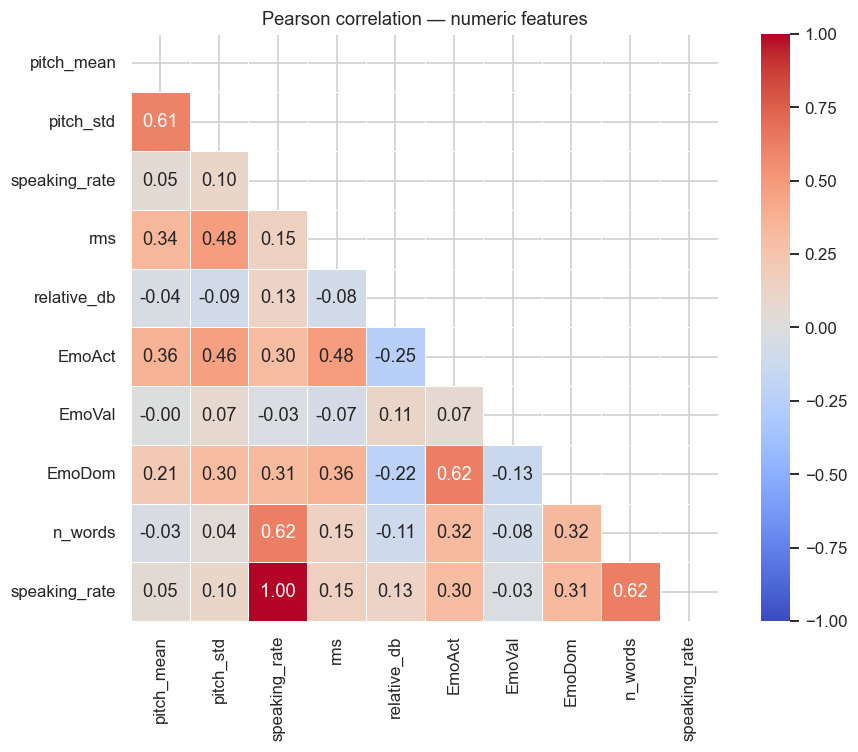

In [21]:
numeric_cols = audio_features + emo_dims + ["n_words", "speaking_rate"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Pearson correlation — numeric features")
plt.tight_layout()
plt.show()

**Results:** Notable correlations:
- **rms ↔ relative_db** (~0.9): near-perfect correlation — both measure loudness. We should keep only one to avoid redundancy.
- **EmoAct ↔ pitch_mean** (positive): higher arousal → higher pitch, consistent with vocal theory.
- **EmoAct ↔ rms** (positive): more emotional intensity → louder voice.
- **EmoVal ↔ EmoDom** (moderate positive): positive emotions tend to feel more in control.

Actionable conclusion for Sprint 2: drop `relative_db` (or `rms`) before building the feature matrix, as they carry almost identical information.

## 14  Summary

| Finding | Detail |
|---------|--------|
| Missing values | None — dataset is complete |
| Duplicates | None found |
| Outliers | `pitch_mean` and `rms` have long right tails (~5–8% outliers); consider log-transform in Sprint 2 |
| Working set | ~6,877 utterances after label cleaning (~31% dropped) |
| Class imbalance | `happy` ~38%, `angry` and `sad` each <20% → use UAR, not Accuracy |
| LOSO validity | Session sizes are balanced (~1,300–1,500 each); class proportions are consistent across sessions |
| Audio signal | All 5 audio features discriminate between classes; `rms` and `relative_db` are redundant |
| Affective space | Classes cluster in Valence–Activation space but overlap; Neutral is the hardest class |
| Text length | Weak discriminator alone; needs lexical content to be useful |
| Redundancy | Drop `relative_db` before training (duplicate of `rms`) |